In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import os
import sys
import torch
import torch.nn as nn
import yaml
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
import numpy as np

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from dataset import load_data
from episode_sampler import EpisodeSampler
from encoder import Encoder
from mamlnet import MAMLNet
from utils import deterministic
from maml_utils import train_maml, plot_maml_history

In [23]:
with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Train

In [24]:
data = "Mnist"
experiment_parameters = config["maml"]
n_way = experiment_parameters["n_way"]
k_shot = experiment_parameters["k_shot"]
q_query = experiment_parameters["q_query"]
meta_batch_size = experiment_parameters["meta_batch_size"]
inner_updates = experiment_parameters["inner_updates"]
meta_iterations = experiment_parameters["meta_iterations"]
in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]
alpha = experiment_parameters["alpha"]
beta = experiment_parameters["beta"]


train_images, train_labels = load_data("train", config[data]["dataset_output_dir"])
val_images, val_labels = load_data("val", config[data]["dataset_output_dir"])

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
model = MAMLNet(encoder, n_way=n_way, protomaml=False)
model.to(device)

train_sampler = EpisodeSampler(images=train_images, labels=train_labels,
                               n_way=n_way, k_shot=k_shot, q_query=q_query)

val_sampler = EpisodeSampler(images=val_images, labels=val_labels,
                             n_way=n_way, k_shot=k_shot, q_query=q_query)

optimizer = torch.optim.Adam(model.parameters(), lr=beta)

In [25]:
deterministic(config["xtra"]["seed"])
maml_history = train_maml(model, train_sampler, val_sampler, optimizer, meta_iterations, meta_batch_size, inner_updates, alpha, device)

Meta-Iterations:   0%|          | 0/200 [00:00<?, ?it/s]

In [26]:
path = "../models/weights/maml_mnist.pth"
model.save(path)

In [27]:
path = "../results/maml_history.yaml"
with open(path, "w") as f:
    yaml.dump(maml_history, f)

### Plots

In [28]:
path = "../results/maml_history.yaml"
with open(path, "r") as f:
    maml_history = yaml.safe_load(f)

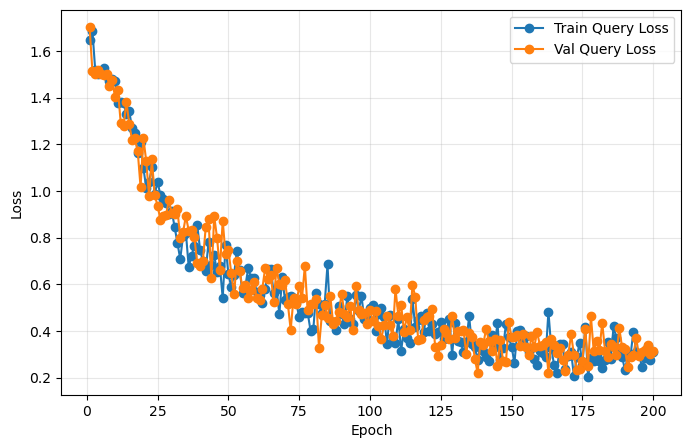

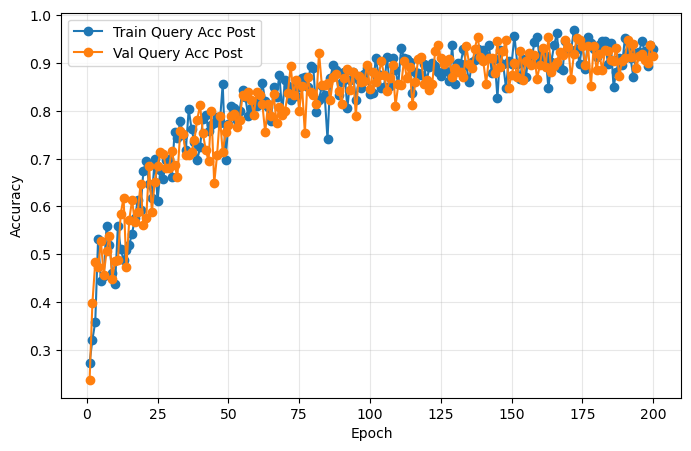

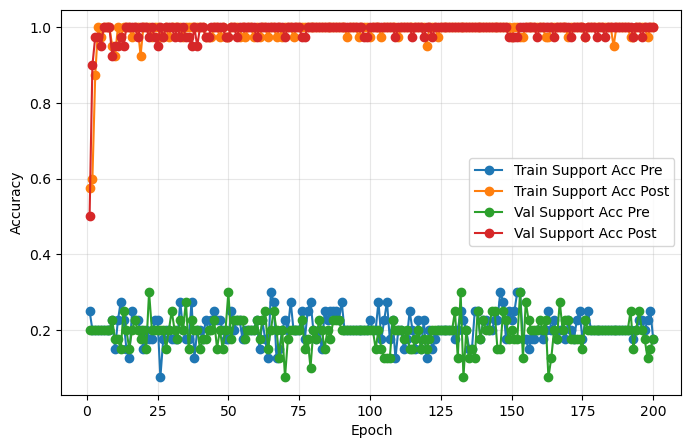

In [29]:
plot_maml_history(maml_history)

In [30]:
# print(f"Train Query Loss: {history['train_query_loss']}")
# print(f"Train Support Acc Pre: {history['train_support_acc_pre']}")
# print(f"Train Support Acc Post: {history['train_support_acc_post']}")
# print(f"Train Query Acc Post: {history['train_query_acc_post']}")

# print(f"Val Query Loss: {history['val_query_loss']}")
# print(f"Val Support Acc Pre: {history['val_support_acc_pre']}")
# print(f"Val Support Acc Post: {history['val_support_acc_post']}")
# print(f"Val Query Acc Post: {history['val_query_acc_post']}")


### ProtoMAML

In [31]:
data = "Mnist"
experiment_parameters = config["protomaml"]
n_way = experiment_parameters["n_way"]
k_shot = experiment_parameters["k_shot"]
q_query = experiment_parameters["q_query"]
meta_batch_size = experiment_parameters["meta_batch_size"]
inner_updates = experiment_parameters["inner_updates"]
meta_iterations = experiment_parameters["meta_iterations"]
in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]
alpha = experiment_parameters["alpha"]
beta = experiment_parameters["beta"]


train_images, train_labels = load_data("train", config[data]["dataset_output_dir"])
val_images, val_labels = load_data("val", config[data]["dataset_output_dir"])

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
model = MAMLNet(encoder, n_way=n_way, protomaml=True)
model.to(device)

train_sampler = EpisodeSampler(images=train_images, labels=train_labels,
                               n_way=n_way, k_shot=k_shot, q_query=q_query)

val_sampler = EpisodeSampler(images=val_images, labels=val_labels,
                             n_way=n_way, k_shot=k_shot, q_query=q_query)

optimizer = torch.optim.Adam(model.parameters(), lr=beta)

In [32]:
deterministic(config["xtra"]["seed"])
protomaml_history = train_maml(model, train_sampler, val_sampler, optimizer, meta_iterations, meta_batch_size, inner_updates, alpha, device)

Meta-Iterations:   0%|          | 0/200 [00:00<?, ?it/s]

In [33]:
path = "../models/weights/protomaml_mnist.pth"
model.save(path)

In [35]:
path = "../results/protomaml_history.yaml"
with open(path, "w") as f:
    yaml.dump(protomaml_history, f)

### Plots

In [36]:
path = "../results/protomaml_history.yaml"
with open(path, "r") as f:
    protomaml_history = yaml.safe_load(f)

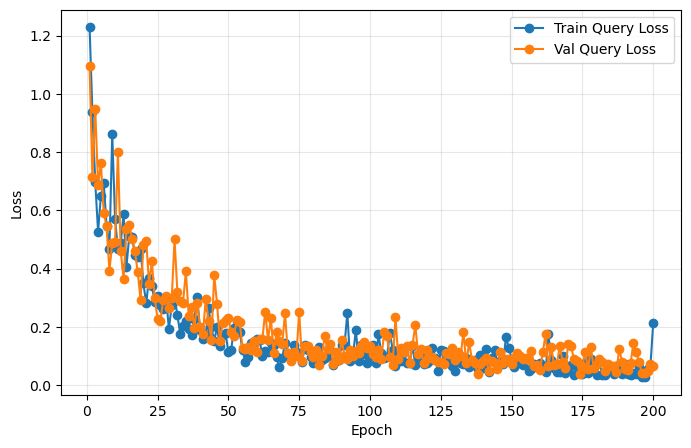

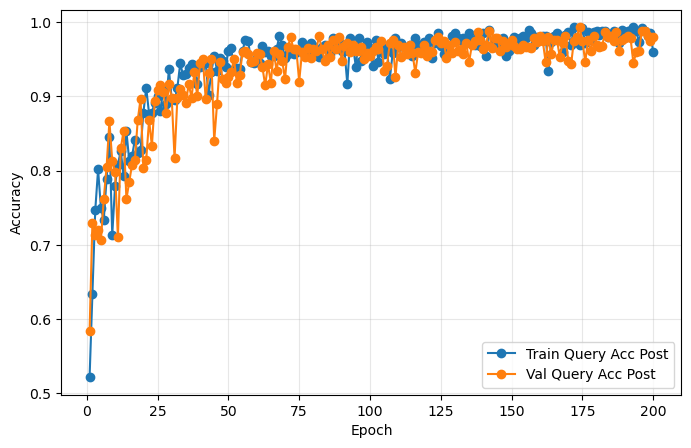

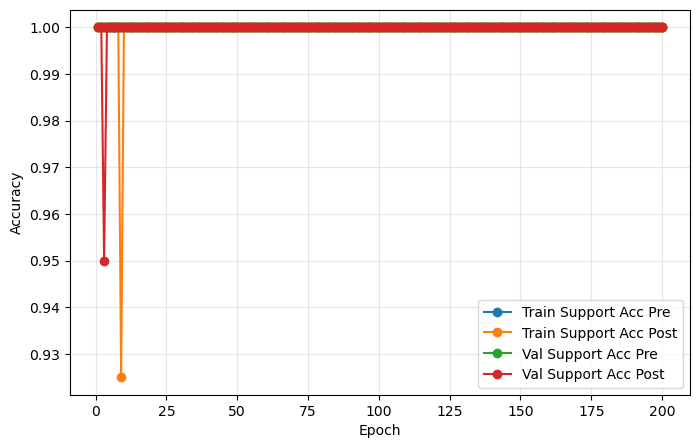

In [37]:
plot_maml_history(protomaml_history)

In [38]:
# print(f"Train Query Loss: {history['train_query_loss']}")
# print(f"Train Support Acc Pre: {history['train_support_acc_pre']}")
# print(f"Train Support Acc Post: {history['train_support_acc_post']}")
# print(f"Train Query Acc Post: {history['train_query_acc_post']}")

# print(f"Val Query Loss: {history['val_query_loss']}")
# print(f"Val Support Acc Pre: {history['val_support_acc_pre']}")
# print(f"Val Support Acc Post: {history['val_support_acc_post']}")
# print(f"Val Query Acc Post: {history['val_query_acc_post']}")
